In [1]:
import argparse
from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw

In [2]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    if wavelength < 380 or wavelength > 750:
        return (0.5, 0.5, 0.5)
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 < wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 < wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 < wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 < wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 < wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (R, G, B)

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    if d.empty:
        return
    lam = 1239.841984 / d[col_Es1].values  # eV -> nm
    colors = [wavelength_to_rgb(w) for w in lam]
    fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=300)
    ax.scatter(d[col_Es1], d[col_f], c=colors, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if xlim is not None:
        ax.set_xlim(*xlim)
    return fig, ax

In [3]:
td_dft_df = pd.read_csv('results/downselection/td-dft/VEE_wb97x-D3.csv')
std2_df = pd.read_csv('results/downselection/std2/std2.csv')
std2_df

,partition,mol,smiles,strength,absorption,E_S1_eV,E_T1_eV,E_ST_eV,f_osc_S1
0,partition_0,mol0017,CC1=N/C(=N\c2ccc(N3c4ccccc4Sc4ccccc43)cc2)c2cc...,0,0,2.8945,1.8092,1.0853,2.135939
1,partition_0,mol0028,CCCCCC1(C)c2cc(-c3ccc(C=C(C#N)C(=O)O)cc3)ccc2-...,0,0,3.6607,2.7515,0.9092,2.180253
2,partition_0,mol0050,O=c1oc2cc3c(cc2c2c1oc1cc(N4c5ccccc5Sc5ccccc54)...,0,0,3.3439,2.5506,0.7933,1.873326
3,partition_0,mol0054,O=[N+]([O-])C(=CNc1ccc(/N=N/c2ccccc2)cc1)[N+](...,0,0,1.5830,1.4901,0.0929,0.072181
4,partition_0,mol0064,O=Cc1ccc2c(c1)C(=O)c1cc(N3CCCCC3)ccc1-2,0,1,1.9716,1.5284,0.4432,0.146227
...,...,...,...,...,...,...,...,...,...
144,partition_1,mol1727,COC(=O)c1nc(-c2ccccc2)oc1-c1ccccc1,4,3,3.9261,2.9425,0.9836,1.065373
145,partition_1,mol1736,CCCCCCCC1(CCCCCCC)c2ccccc2-c2ccc(C#Cc3ccc4c(c3...,4,4,3.9733,3.3014,0.6719,2.786118
146,partition_1,mol1750,[CH]1Nc2cc3ccccc3cc2[C@H]2C=C[C@H]12,4,4,1.9817,1.9817,0.0000,0.045331
147,partition_1,mol1752,OC(O)CNc1ccc(/C=C/c2ccccn2)cc1,4,4,3.7697,2.7069,1.0628,1.706894


In [4]:
print('Print std2 columns: ', std2_df.columns)
print('Print td_dft columns: ', td_dft_df.columns)

Print std2 columns:  Index(['partition', 'mol', 'smiles', 'strength', 'absorption', 'E_S1_eV',
       'E_T1_eV', 'E_ST_eV', 'f_osc_S1'],
      dtype='object')
Print td_dft columns:  Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)'],
      dtype='object')


Context:
Print std2 columns:  Index(['partition', 'mol', 'smiles', 'strength', 'absorption', 'E_S1_eV',
       'E_T1_eV', 'E_ST_eV', 'f_osc_S1'],
      dtype='object')
Print td_dft columns:  Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)'],
      dtype='object')

(<Figure size 1980x1560 with 1 Axes>,
 <Axes: title={'center': 'TD-DFT S1 Energy vs Oscillator Strength '}, xlabel='S1 Energy (eV)', ylabel='Oscillator Strength'>)

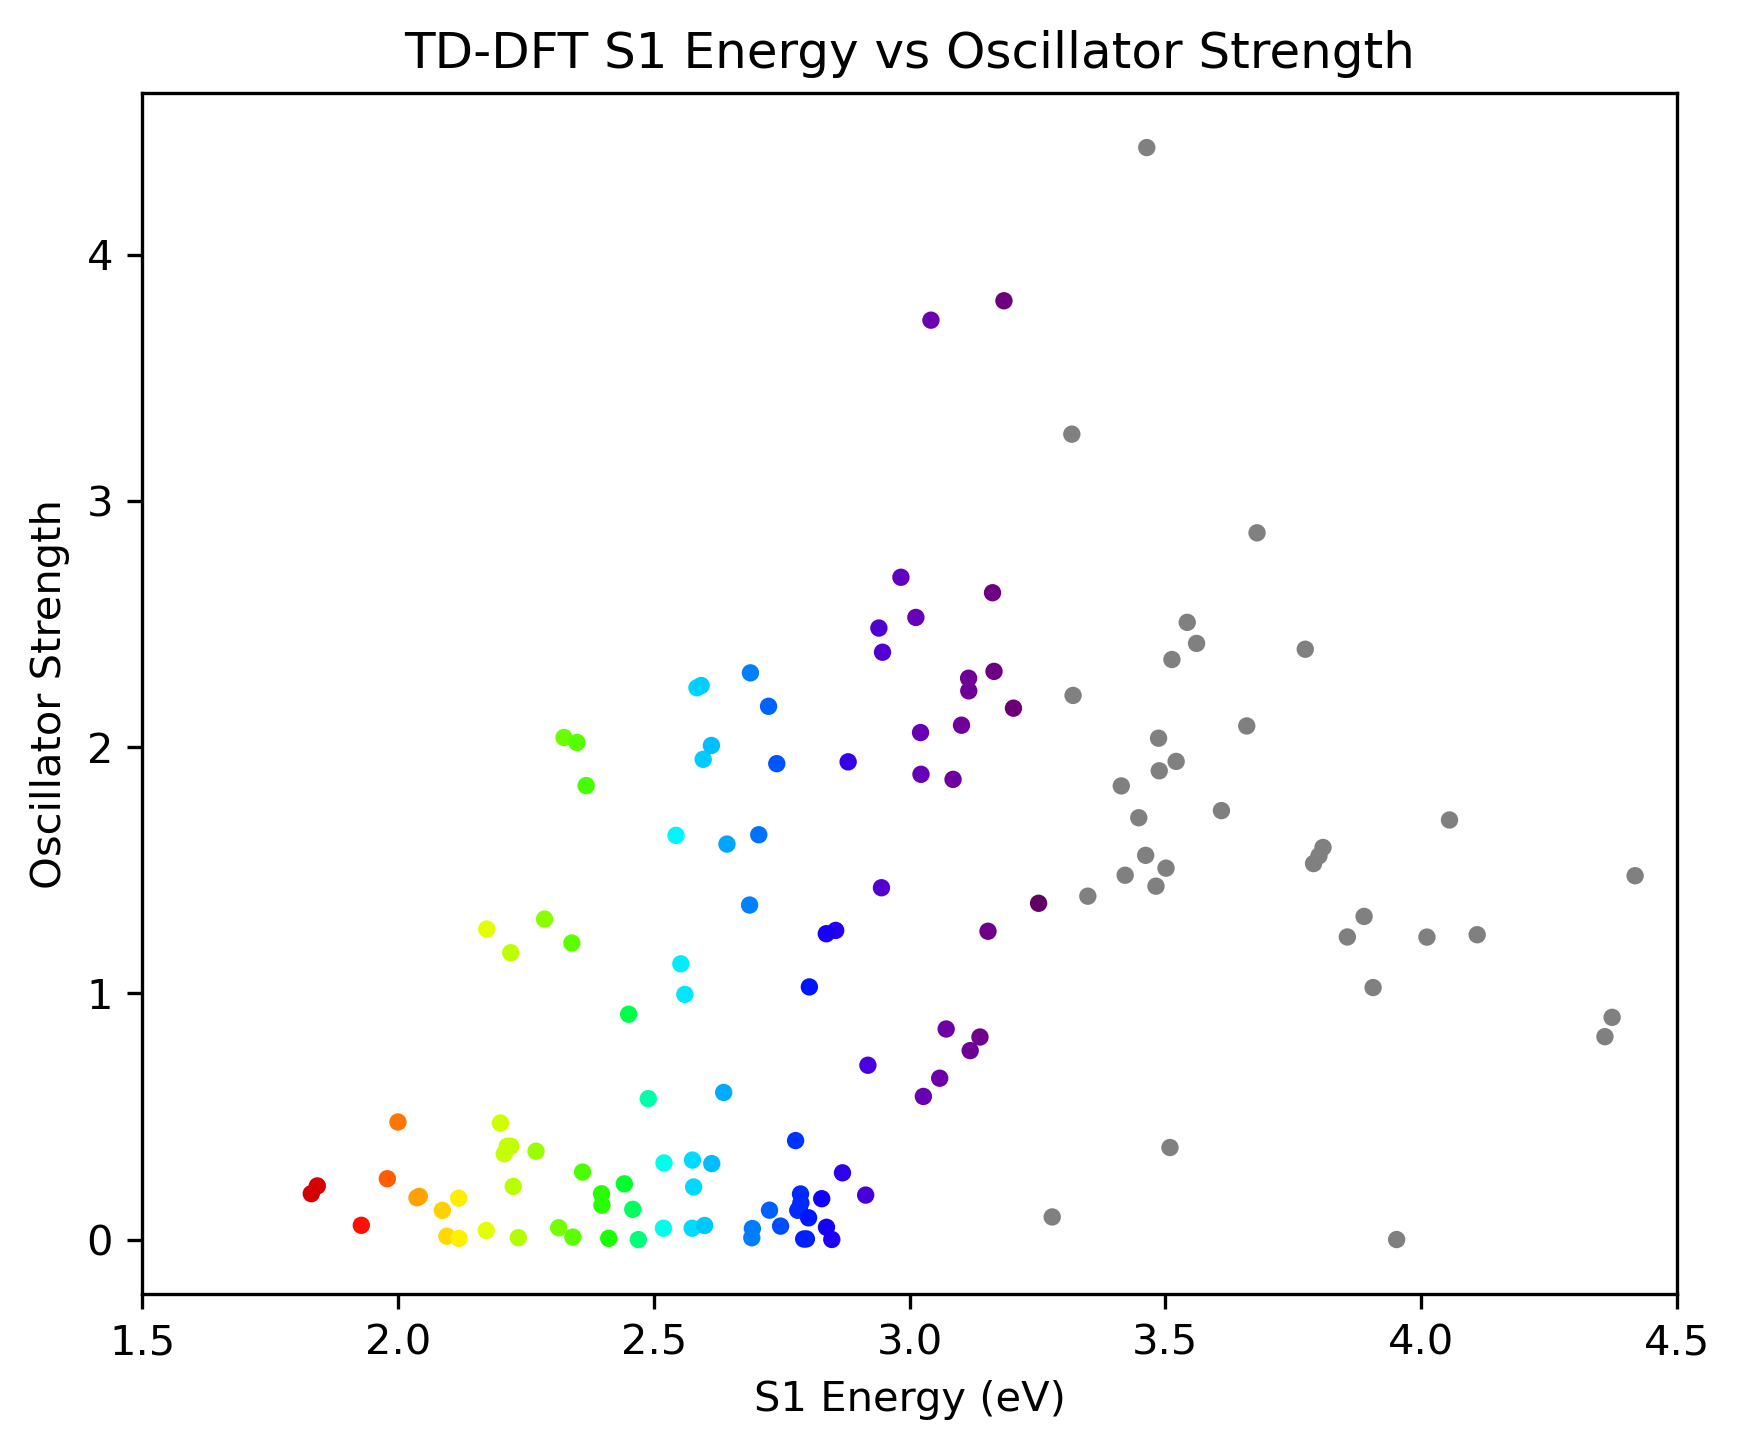

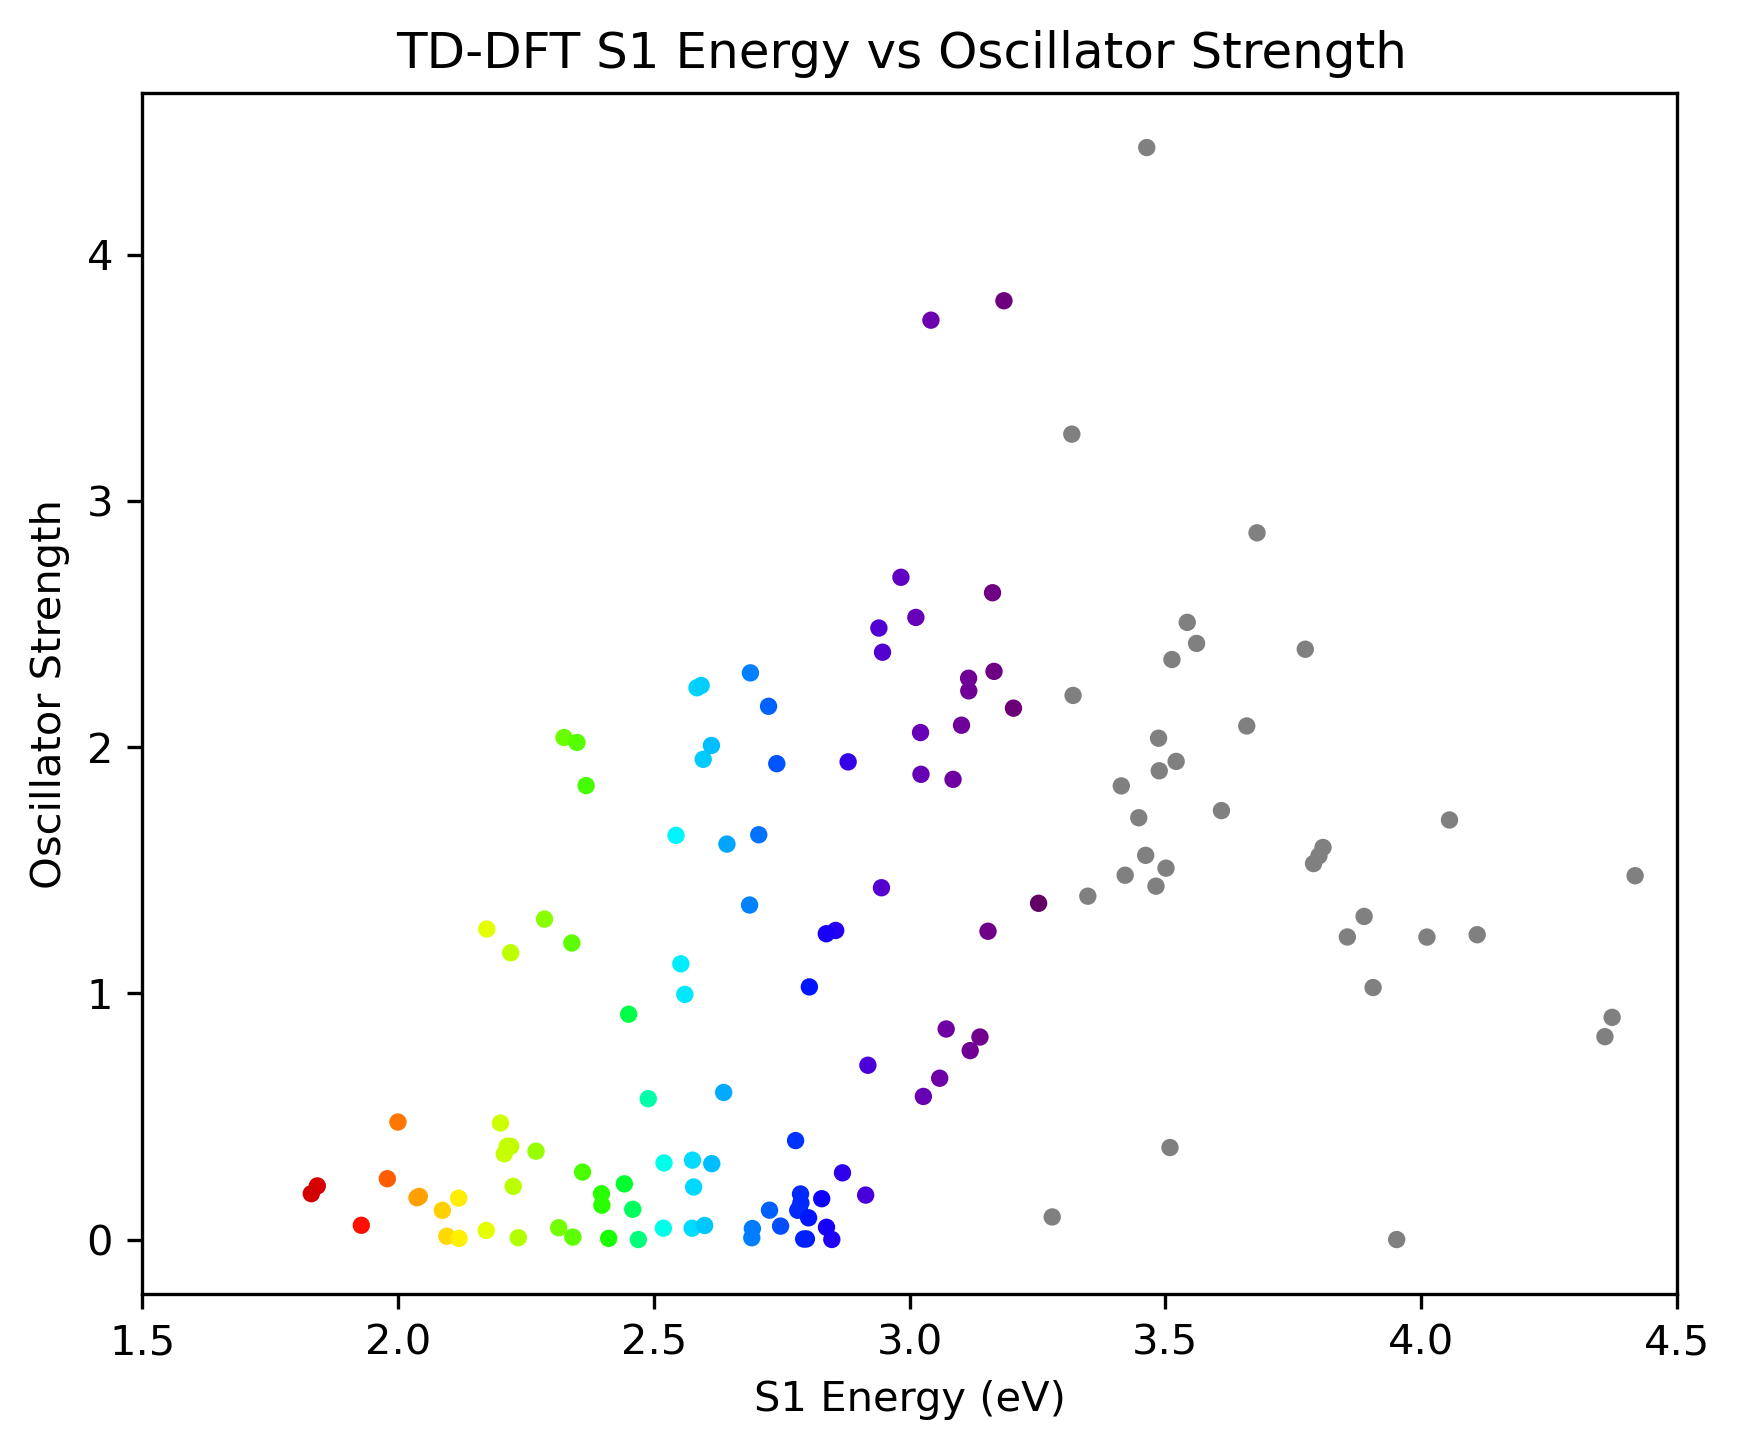

In [5]:
 # plot S1 energy vs oscillator strength for TD-DFT without and with SOC correction

scatter_colored(
    td_dft_df,
    col_Es1='E_S1(eV)',
    col_f='osc_S1',
    title='TD-DFT S1 Energy vs Oscillator Strength',
    xlab='S1 Energy (eV)',
    ylab='Oscillator Strength',
    xlim=(1.5, 4.5)
)   
scatter_colored(
    td_dft_df,
    col_Es1='E_S1_SOC(eV)',
    col_f='osc_S1_SOC',
    title='TD-DFT S1 Energy vs Oscillator Strength ',
    xlab='S1 Energy (eV)',
    ylab='Oscillator Strength',
    xlim=(1.5, 4.5)
)

In [6]:
# for std2, drop molecules that do not have TD-DFT results
std2_df = std2_df[std2_df['mol'].isin(td_dft_df['mol'])]

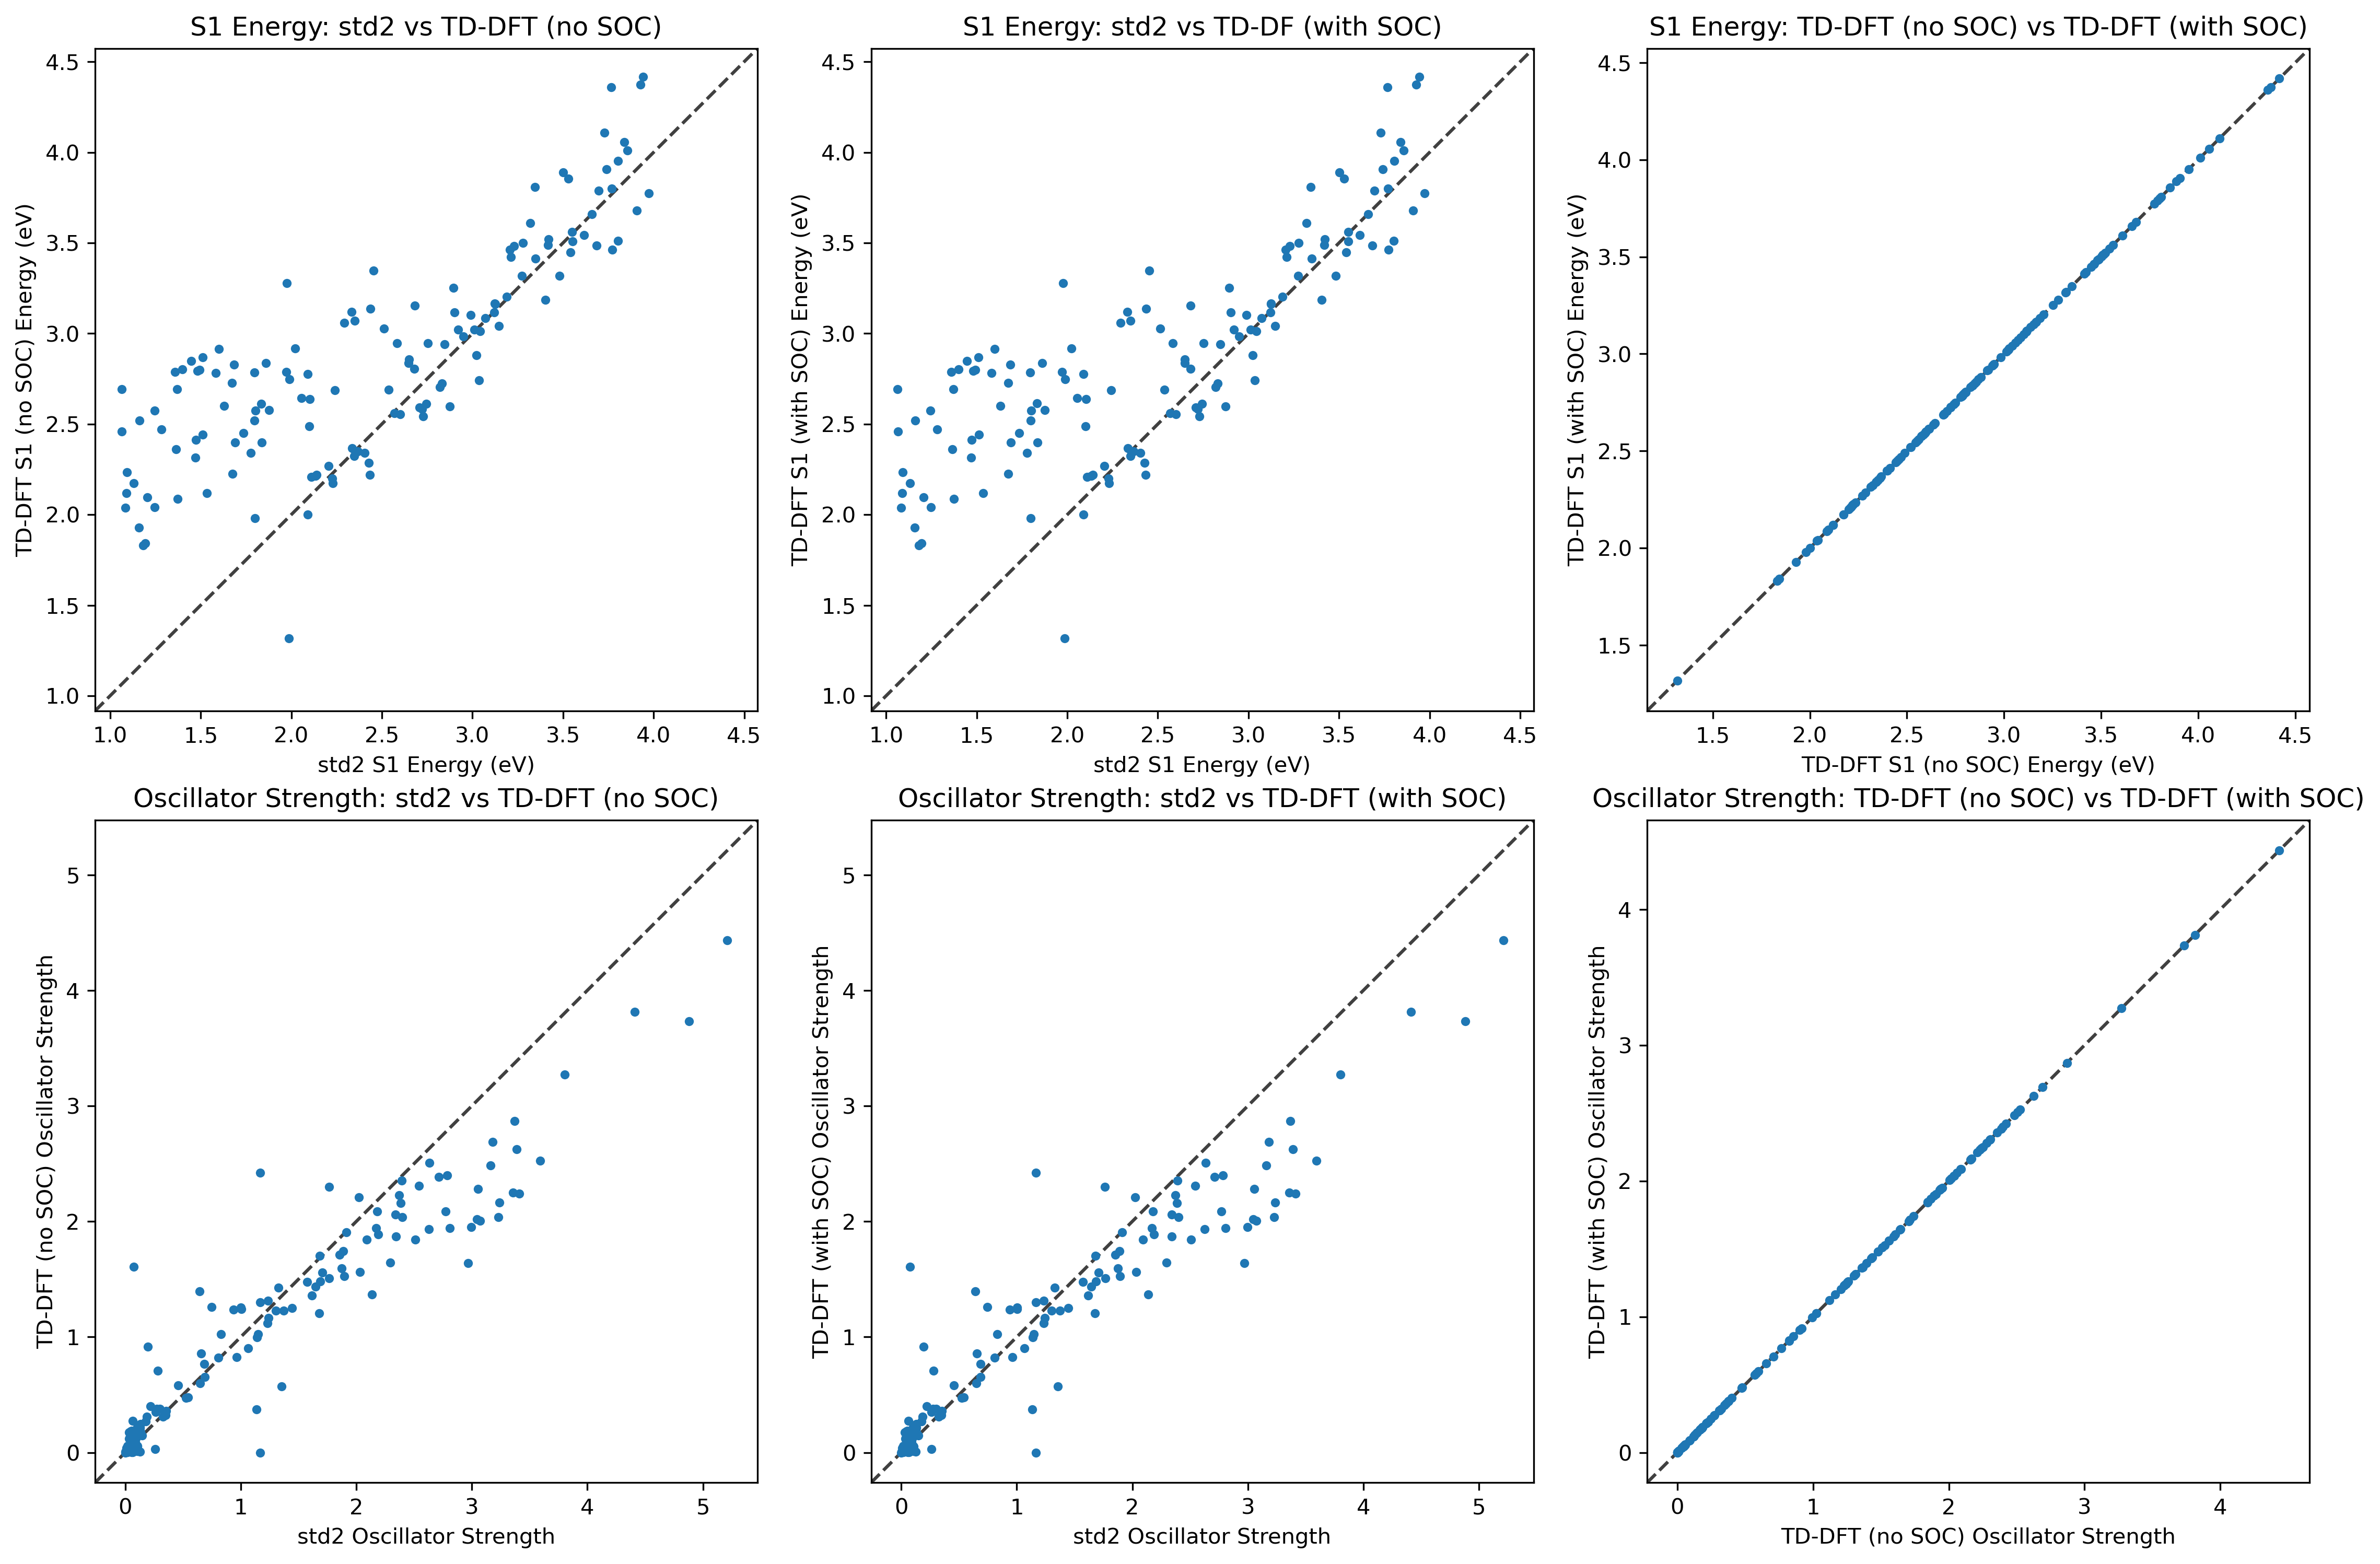

In [7]:
# Plot S1 energy std2 vs TD-DFT without SOC correction. std2 S1 energy 
#  vs TD-DFT with SOC correction and TD-DFT without vs with SOC correction, all in one figure with 
# Then do the same for oscillator strength, all in one figure with subplots 2x3
fig, axs = plt.subplots(2, 3, figsize=(15, 10), dpi=300)
# S1 energy plots 
axs[0, 0].scatter(std2_df['E_S1_eV'], td_dft_df['E_S1(eV)'], s=10)
axs[0, 0].set_title('S1 Energy: std2 vs TD-DFT (no SOC)')
axs[0, 0].set_xlabel('std2 S1 Energy (eV)')
axs[0, 0].set_ylabel('TD-DFT S1 (no SOC) Energy (eV)')

axs[0, 1].scatter(std2_df['E_S1_eV'], td_dft_df['E_S1_SOC(eV)'], s=10)
axs[0, 1].set_title('S1 Energy: std2 vs TD-DF (with SOC)')
axs[0, 1].set_xlabel('std2 S1 Energy (eV)')
axs[0, 1].set_ylabel('TD-DFT S1 (with SOC) Energy (eV)')

axs[0, 2].scatter(td_dft_df['E_S1(eV)'], td_dft_df['E_S1_SOC(eV)'], s=10)
axs[0, 2].set_title('S1 Energy: TD-DFT (no SOC) vs TD-DFT (with SOC)')
axs[0, 2].set_xlabel('TD-DFT S1 (no SOC) Energy (eV)')
axs[0, 2].set_ylabel('TD-DFT S1 (with SOC) Energy (eV)')
# Oscillator strength plots
axs[1, 0].scatter(std2_df['f_osc_S1'], td_dft_df['osc_S1'], s=10)
axs[1, 0].set_title('Oscillator Strength: std2 vs TD-DFT (no SOC)')
axs[1, 0].set_xlabel('std2 Oscillator Strength')
axs[1, 0].set_ylabel('TD-DFT (no SOC) Oscillator Strength')

axs[1, 1].scatter(std2_df['f_osc_S1'], td_dft_df['osc_S1_SOC'], s=10)
axs[1, 1].set_title('Oscillator Strength: std2 vs TD-DFT (with SOC)')
axs[1, 1].set_xlabel('std2 Oscillator Strength')
axs[1, 1].set_ylabel('TD-DFT (with SOC) Oscillator Strength')

axs[1, 2].scatter(td_dft_df['osc_S1'], td_dft_df['osc_S1_SOC'], s=10)
axs[1, 2].set_title('Oscillator Strength: TD-DFT (no SOC) vs TD-DFT (with SOC)')
axs[1, 2].set_xlabel('TD-DFT (no SOC) Oscillator Strength')
axs[1, 2].set_ylabel('TD-DFT (with SOC) Oscillator Strength')



# Put a diagonal dashed line in each subplot
for i in range(2):
    for j in range(3):
        ax = axs[i, j]
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
plt.tight_layout() 

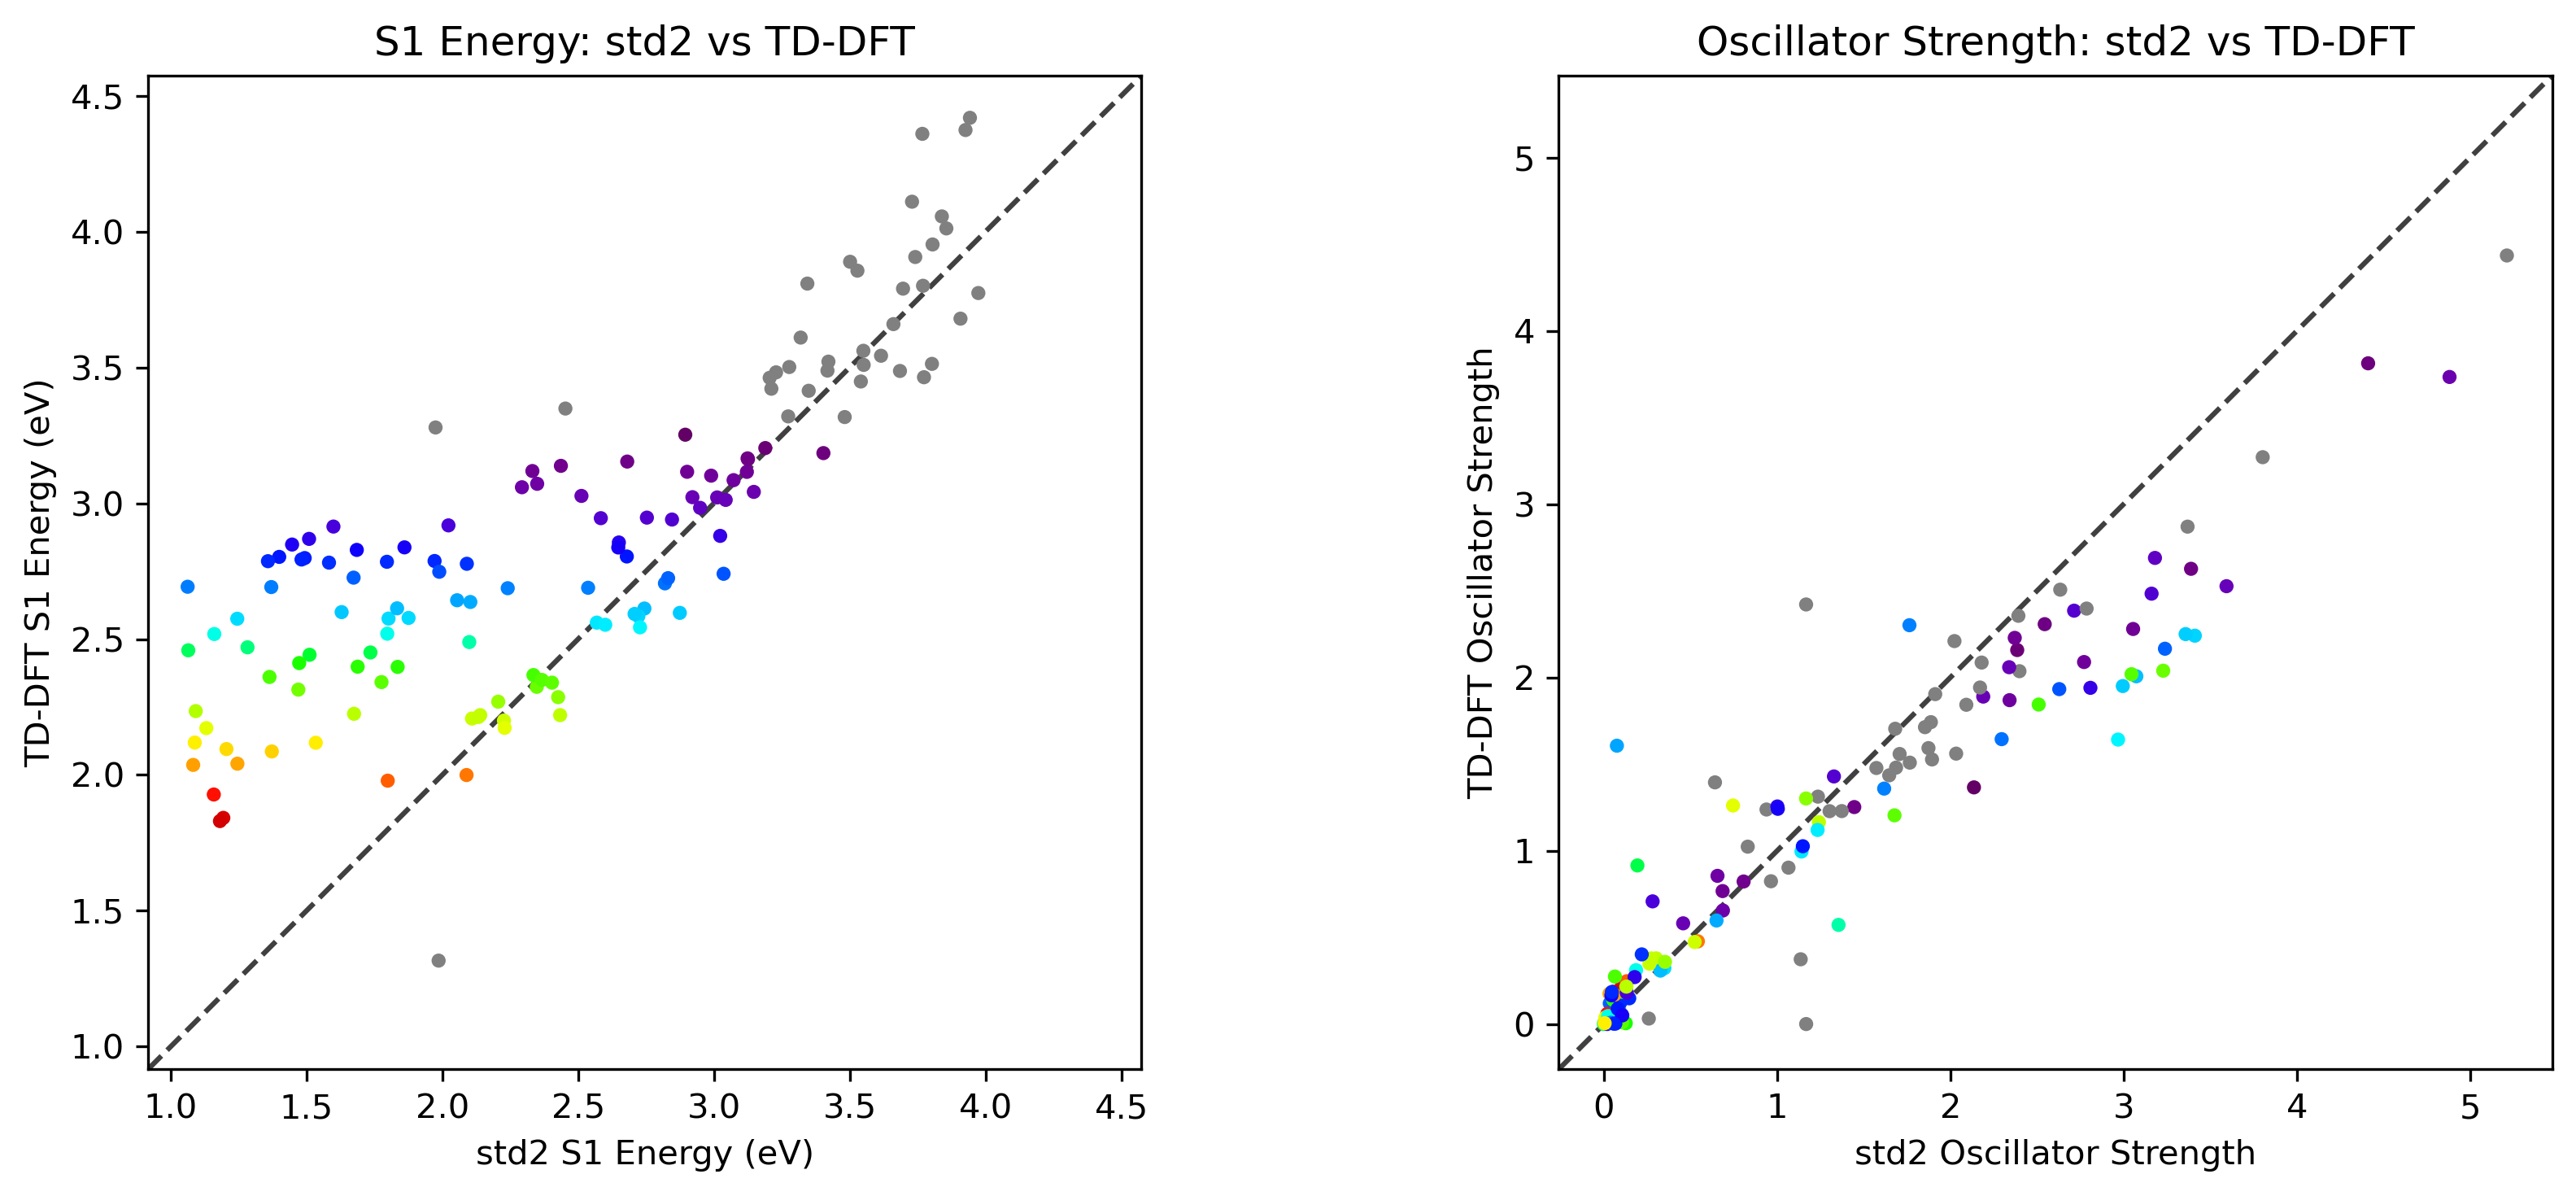

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ---------------------------- #
# 1. S1 ENERGY PLOT
# ---------------------------- #

d_energy = pd.DataFrame({
    'std2_E_S1_eV': std2_df['E_S1_eV'].to_numpy(),
    'td_dft_E_S1_SOC(eV)': td_dft_df['E_S1_SOC(eV)'].to_numpy(),
    'wl_S1_SOC(nm)': td_dft_df['wl_S1_SOC(nm)'].to_numpy(),
})

colors_energy = [wavelength_to_rgb(w) for w in d_energy['wl_S1_SOC(nm)']]

axs[0].scatter(
    d_energy['std2_E_S1_eV'],
    d_energy['td_dft_E_S1_SOC(eV)'],
    c=colors_energy,
    s=10
)

axs[0].set_title('S1 Energy: std2 vs TD-DFT')
axs[0].set_xlabel('std2 S1 Energy (eV)')
axs[0].set_ylabel('TD-DFT S1 Energy (eV)')

# diagonal
lims = [
    np.min([axs[0].get_xlim(), axs[0].get_ylim()]),
    np.max([axs[0].get_xlim(), axs[0].get_ylim()])
]
axs[0].plot(lims, lims, 'k--', alpha=0.75, zorder=0)
axs[0].set_aspect('equal')
axs[0].set_xlim(lims)
axs[0].set_ylim(lims)


# ---------------------------- #
# 2. OSCILLATOR STRENGTH PLOT
# ---------------------------- #

d_osc = pd.DataFrame({
    'std2_f_osc_S1': std2_df['f_osc_S1'].to_numpy(),
    'td_dft_osc_S1_SOC': td_dft_df['osc_S1_SOC'].to_numpy(),
    'wl_S1_SOC(nm)': td_dft_df['wl_S1_SOC(nm)'].to_numpy(),
})

colors_osc = [wavelength_to_rgb(w) for w in d_osc['wl_S1_SOC(nm)']]

axs[1].scatter(
    d_osc['std2_f_osc_S1'],
    d_osc['td_dft_osc_S1_SOC'],
    c=colors_osc,
    s=10
)

axs[1].set_title('Oscillator Strength: std2 vs TD-DFT')
axs[1].set_xlabel('std2 Oscillator Strength')
axs[1].set_ylabel('TD-DFT Oscillator Strength')

# diagonal
lims = [
    np.min([axs[1].get_xlim(), axs[1].get_ylim()]),
    np.max([axs[1].get_xlim(), axs[1].get_ylim()])
]
axs[1].plot(lims, lims, 'k--', alpha=0.75, zorder=0)
axs[1].set_aspect('equal')
axs[1].set_xlim(lims)
axs[1].set_ylim(lims)

plt.tight_layout()


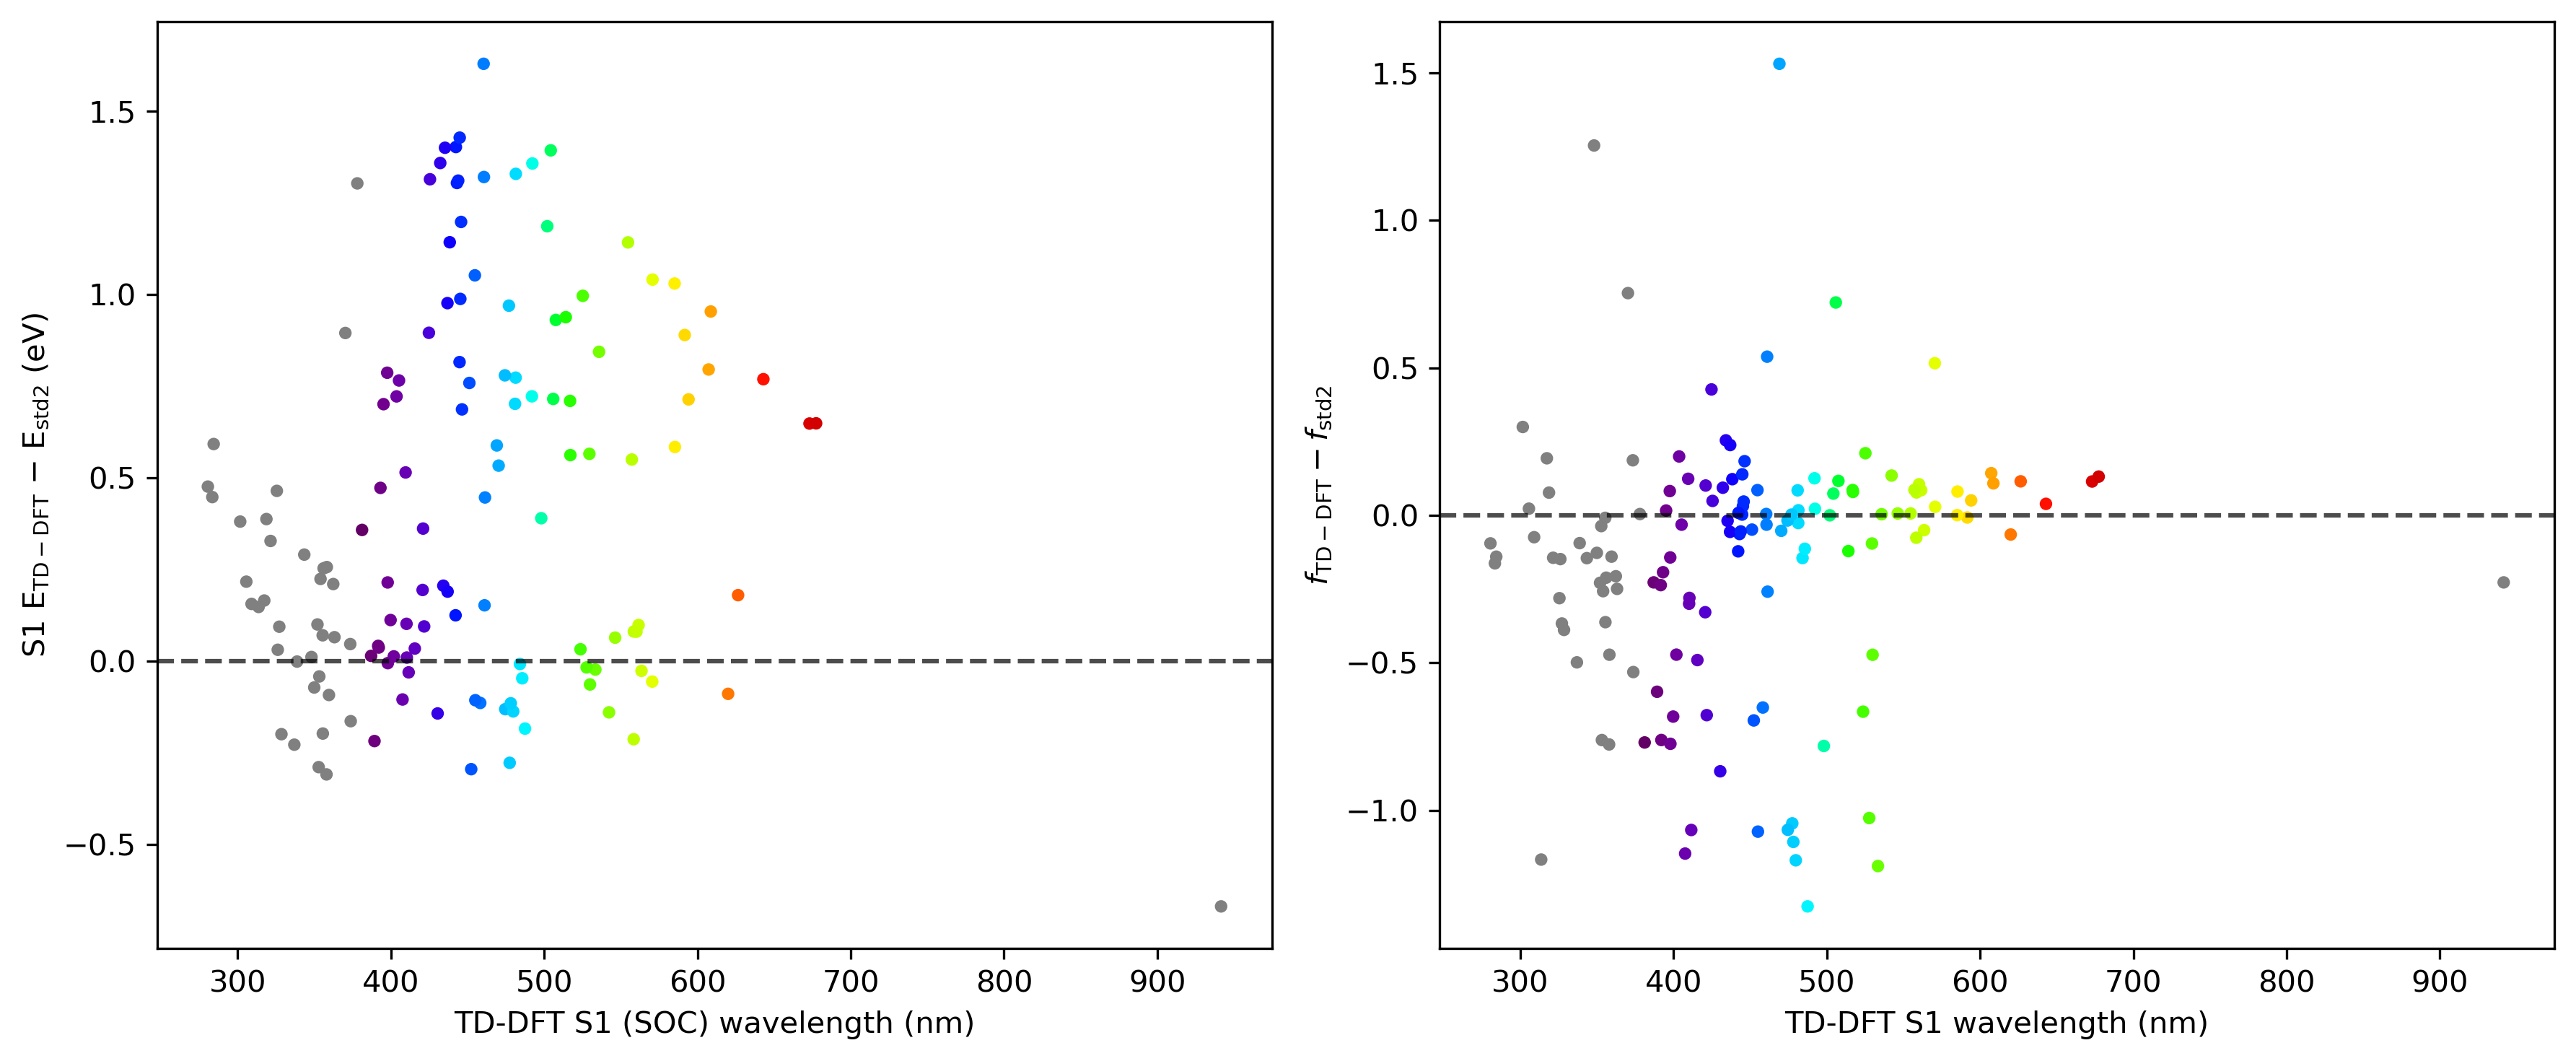

In [9]:
# plot S1 energy of TD-DFT (SOC) - std2 as a function of TD-DFT (SOC) wavelength,
# with colors and a dashed line at y=0
# then the same for oscillator strength, all in a 1x2 figure

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ---------------------------- #
# 1. ΔE(S1) = TD-DFT(SOC) - std2 vs wavelength
# ---------------------------- #

E_s1_soc = td_dft_df['E_S1_SOC(eV)'].to_numpy()
E_s1_std2 = std2_df['E_S1_eV'].to_numpy()
wl_s1_soc = td_dft_df['wl_S1_SOC(nm)'].to_numpy()

delta_E = E_s1_soc - E_s1_std2  # TD-DFT(SOC) - std2

colors_energy = [wavelength_to_rgb(w) for w in wl_s1_soc]

axs[0].scatter(
    wl_s1_soc,
    delta_E,
    c=colors_energy,
    s=10
)

axs[0].axhline(0.0, ls='--', c='k', alpha=0.7)
axs[0].set_xlabel('TD-DFT S1 (SOC) wavelength (nm)')
axs[0].set_ylabel(r'S1 E$_{\mathrm{ TD-DFT}}$ − E$_{\mathrm{std2}}$ (eV)')


# ---------------------------- #
# 2. Δf(S1) = TD-DFT(SOC) - std2 vs wavelength
# ---------------------------- #

f_s1_soc = td_dft_df['osc_S1_SOC'].to_numpy()
f_s1_std2 = std2_df['f_osc_S1'].to_numpy()
# same wl_s1_soc as above

delta_f = f_s1_soc - f_s1_std2  # TD-DFT(SOC) - std2

colors_osc = [wavelength_to_rgb(w) for w in wl_s1_soc]

axs[1].scatter(
    wl_s1_soc,
    delta_f,
    c=colors_osc,
    s=10
)

axs[1].axhline(0.0, ls='--', c='k', alpha=0.7)
axs[1].set_xlabel('TD-DFT S1 wavelength (nm)')
# write osc strength difference ylabel in latex
axs[1].set_ylabel(r'$f_{\mathrm{TD-DFT}} - f_{\mathrm{std2}}$')

plt.tight_layout()
plt.show()
plt.close()

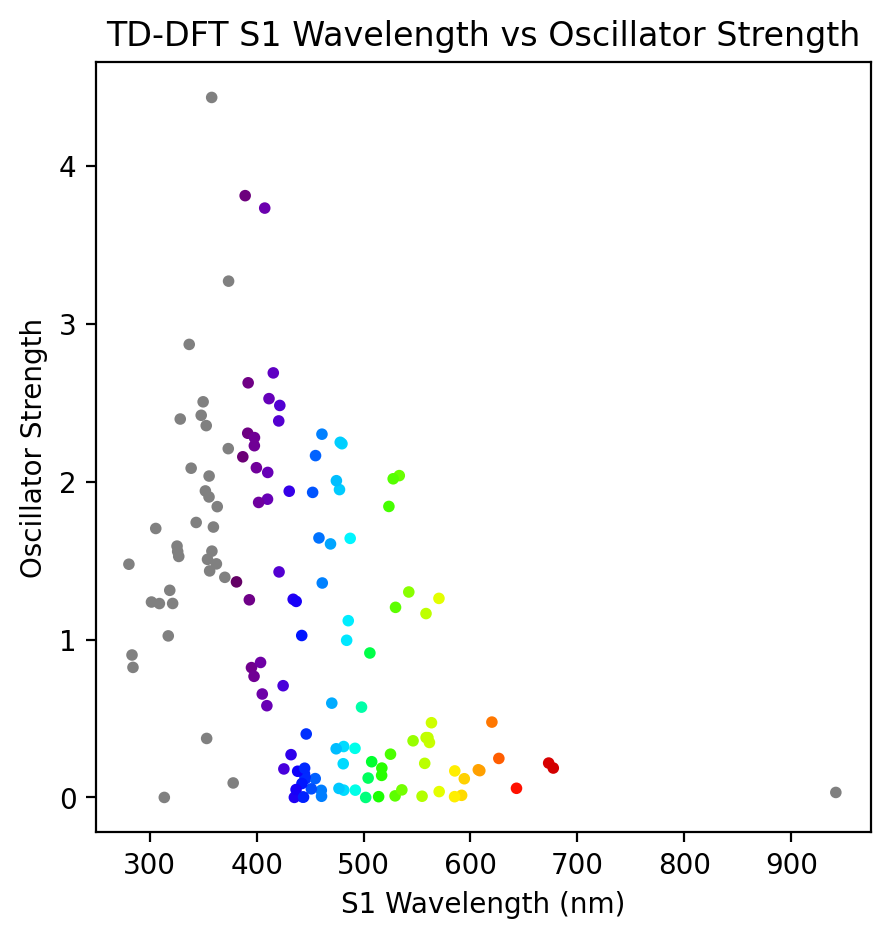

In [13]:
# Plot S1 wavelength vs oscillator strength for TD-DFT with SOC correction without scatter_colored function
# use the wavelength from wl_S1(nm)
fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
wavelengths = td_dft_df['wl_S1_SOC(nm)'].to_numpy()
osc_strengths = td_dft_df['osc_S1_SOC'].to_numpy()
colors = [wavelength_to_rgb(w) for w in wavelengths]
ax.scatter(wavelengths, osc_strengths, c=colors, s=10)
ax.set_title('TD-DFT S1 Wavelength vs Oscillator Strength')
ax.set_xlabel('S1 Wavelength (nm)')
ax.set_ylabel('Oscillator Strength')
ax.set_xlim(250, None)
plt.show()
plt.close()




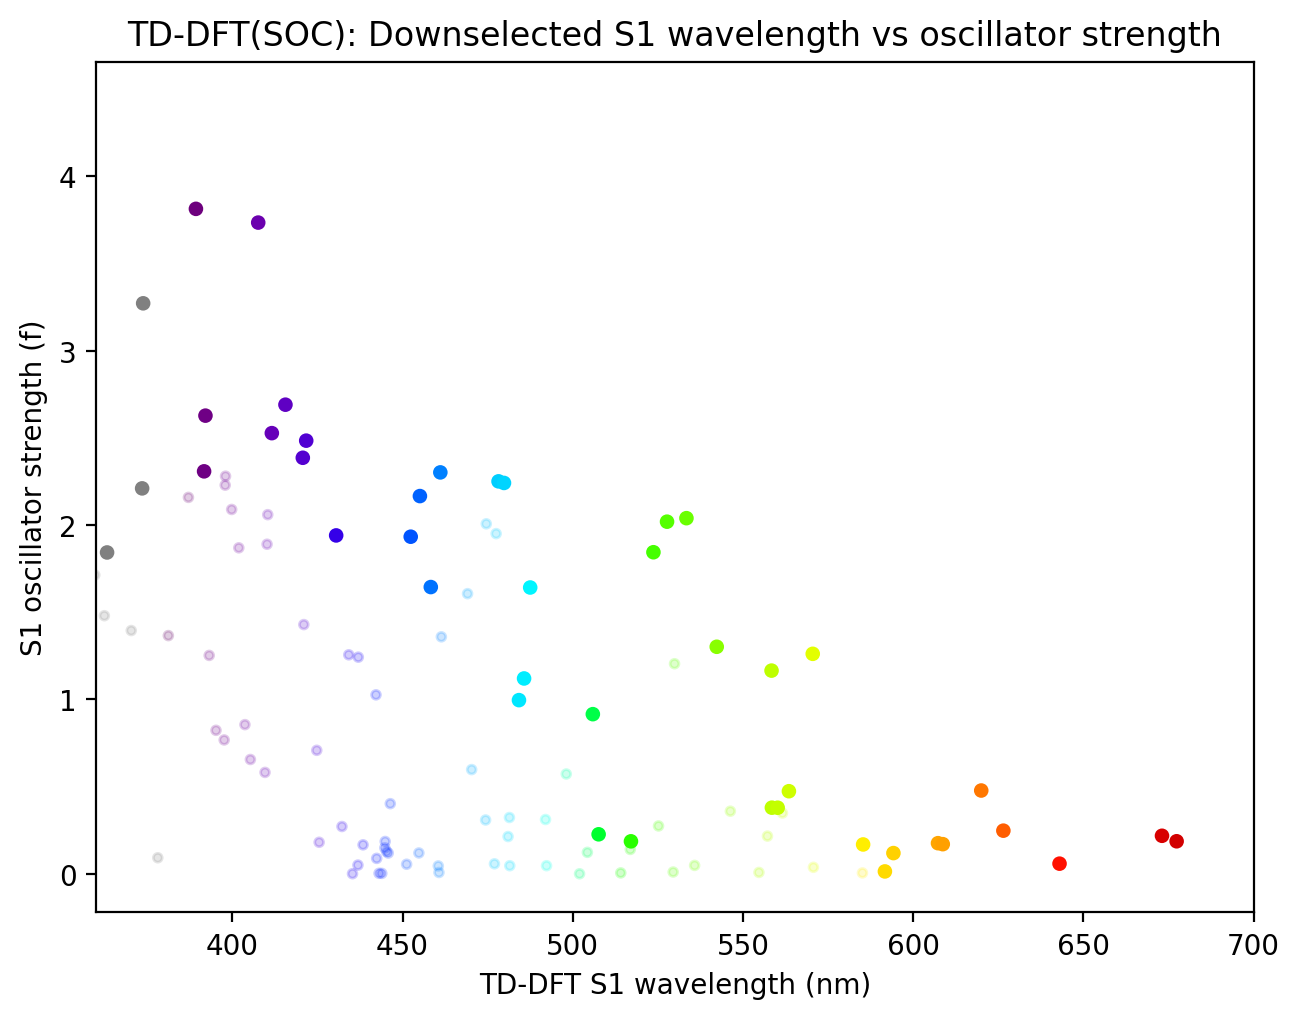

In [ ]:
# --- data ---
wavelength = td_dft_df['wl_S1_SOC(nm)'].to_numpy()
osc        = td_dft_df['osc_S1_SOC'].to_numpy()

# wavelength bins: 20 nm from 250 to 800
wl_bins = np.arange(360, 700, 20)

# assign each molecule to a bin via wavelength
wl_bin_indices = np.digitize(wavelength, wl_bins)

selected_indices = []

for b in range(1, len(wl_bins)):
    idx_bin = np.where(wl_bin_indices == b)[0]
    if len(idx_bin) == 0:
        continue

    n_bin = len(idx_bin)
    # select at least 3, or 50% of the bin, but never more than the bin itself
    n_select = min(max(3, int(n_bin * 0.1)), n_bin)

    osc_bin = osc[idx_bin]
    sorted_idx = idx_bin[np.argsort(-osc_bin)]  # sort by osc, descending
    selected_indices.extend(sorted_idx[:n_select].tolist())

# build downselected and rest sets
down_df = td_dft_df.loc[selected_indices]
rest_df = td_dft_df.drop(index=selected_indices)

down_df.to_csv(
    'results/downselection/td-dft/top_td_dft_downselected.csv',
    index=False
)

# -------- plot wavelength vs oscillator strength --------
fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=200)

# discarded data (colored by wavelength, low alpha)
wl_rest  = rest_df['wl_S1_SOC(nm)'].to_numpy()
osc_rest = rest_df['osc_S1_SOC'].to_numpy()
colors_rest = [wavelength_to_rgb(w) for w in wl_rest]
ax.scatter(wl_rest, osc_rest, c=colors_rest, s=10, alpha=0.2)

# selected data (colored by wavelength, full alpha)
wl_sel  = down_df['wl_S1_SOC(nm)'].to_numpy()
osc_sel = down_df['osc_S1_SOC'].to_numpy()
colors_sel = [wavelength_to_rgb(w) for w in wl_sel]
ax.scatter(wl_sel, osc_sel, c=colors_sel, s=18, alpha=1.0)

ax.set_xlabel('TD-DFT S1 wavelength (nm)')
ax.set_ylabel('S1 oscillator strength (f)')
ax.set_title('TD-DFT(SOC): Downselected S1 wavelength vs oscillator strength')
ax.set_xlim(360, 700)

plt.tight_layout()
plt.show()
plt.close()


In [14]:
# draw td-dft molecule with largest wavelength
td_dft_sorted_df = td_dft_df.sort_values(by='E_S1_SOC(eV)')
molecule_smiles = td_dft_sorted_df.iloc[0]['smiles']
mol = Chem.MolFromSmiles(molecule_smiles)
img = Draw.MolToImage(mol, size=(300, 300))
img.show()
print('Wavelength of molecule with highest TD-DFT(SOC) S1 wavelength: ', td_dft_sorted_df.iloc[0]['wl_S1_SOC(nm)'])
print('smiles: ', molecule_smiles)

Wavelength of molecule with highest TD-DFT(SOC) S1 wavelength:  941.6
smiles:  CCCCCCCCCCCCCOC1=CC=c2c1ccc1c3c(ccc21)C=CC=3
